<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Feature-Engineered Dataset Loading](#feature-engineered-dataset-loading)
- [Feature Quality Check](#feature-quality-check)
- [Information Gain Exploration](#information-gain-exploration)
- [Random Forest Feature Importance Comparison](#random-forest-feature-importance-comparison)
- [Feature Exploration Result Saving](#feature-exploration-result-saving)
- [Top Feature Selection for Modeling](#top-feature-selection-for-modeling)
- [Engineered Feature Model Saving](#engineered-feature-model-saving)
- [Main Function Check](#main-function-check)

</div>

##### **IMPORTANT**:
- YOU MUST HAVE THE FEATURE-ENGINEERED DATASET `../Datasets/highest_snr_feature_engineered.parquet`
- This notebook assumes the feature-engineered dataset was created from the reduced SNR-30-only dataset
- The primary goal here is to rank engineered features by information gain / mutual information before model training

---

##### **ORIENTATION**:
- This notebook explores engineered I/Q signal features to identify which features are most informative for predicting modulation type.
- The primary metric is information gain, implemented through sklearn's `mutual_info_classif`.
- A Random Forest feature-importance comparison is also included as a secondary model-based check.

---

##### **SUMMARY**:
- Load feature-engineered dataset
- Validate feature quality
- Calculate information gain for each engineered feature
- Optionally compare information gain against Random Forest importance
- Save feature rankings for future modeling
- Save selected top feature names for later model training
- Save the engineered-feature Random Forest model and a reproducibility JSON

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Import helper module for feature-engineering exploration
import highest_snr_feature_engineering_explore as e

# Helpful when actively editing highest_snr_feature_engineering_explore.py
# Basically, I dont have to reload the entire notebook everytime
from importlib import reload
e = reload(e)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Feature-Engineered Dataset Loading

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- Load the feature-engineered dataset from parquet
- Identify model-ready engineered feature columns
- Summarize class balance, SNR values, and dataset shape

In [2]:
# Load the feature-engineered dataset created from the reduced highest-SNR dataset
df_features = e.load_feature_engineered_dataset(
    feature_dataset_filepath=e.FEATURE_ENGINEERED_DATASET_PARQUET
)

# Identify columns that are engineered features rather than metadata/targets
feature_columns = e.get_feature_columns(df_features)

# Summarize the dataset before exploration
e.summarize_feature_engineered_dataset(
    df_features=df_features,
    feature_columns=feature_columns
)

Feature-engineered dataset loaded successfully!
Dataset filepath: ../Datasets/highest_snr_feature_engineered.parquet
Dataset shape: (24000, 109)

Number of feature columns: 105
FEATURE-ENGINEERED DATASET SUMMARY
Dataset shape: (24000, 109)
Number of rows/signals: 24000
Number of engineered features: 105

Modulation distribution:
modulation_type
128APSK      1000
128QAM       1000
16APSK       1000
16PSK        1000
16QAM        1000
256QAM       1000
32APSK       1000
32PSK        1000
32QAM        1000
4ASK         1000
64APSK       1000
64QAM        1000
8ASK         1000
8PSK         1000
AM-DSB-SC    1000
AM-DSB-WC    1000
AM-SSB-SC    1000
AM-SSB-WC    1000
BPSK         1000
FM           1000
GMSK         1000
OOK          1000
OQPSK        1000
QPSK         1000
Name: count, dtype: int64

SNR distribution:
snr
30    24000
Name: count, dtype: int64

First 5 rows:
   signal_index  modulation_id modulation_type  snr    mean_I     std_I  \
0             0              0             O

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Feature Quality Check

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- Check missing values, infinite values, and constant features
- Save a feature-quality CSV report to `../Reports/highest_snr_feature_quality.csv`
- This keeps bad or unusable features from silently affecting information gain and later modeling

In [3]:
# Check feature quality before calculating information gain
feature_quality_df = e.check_feature_quality(
    df_features=df_features,
    feature_columns=feature_columns,
    output_filepath=e.FEATURE_QUALITY_OUTPUT_PATH,
    save_results=True
)

feature_quality_df.head(15)

FEATURE QUALITY CHECK
Total features checked: 105
Constant features: 0
Features with missing values: 0
Features with infinite values: 0

Top feature quality issues:
   feature  num_missing  num_infinite  num_unique  is_constant      mean      std        min       max
    mean_I            0             0       23995        False -0.009671 2.187662 -23.275093 26.465673
     std_I            0             0       23879        False  0.665111 0.180014   0.005271  1.258249
     min_I            0             0       23972        False -1.391574 2.219330 -25.749222 24.613077
     max_I            0             0       23961        False  1.373605 2.220663 -20.400421 28.459764
  median_I            0             0       23995        False -0.009875 2.189590 -23.275431 26.608673
   range_I            0             0       23953        False  2.765179 0.800170   0.027416  5.884624
     q25_I            0             0       23974        False -0.563113 2.196319 -23.855545 26.221281
     q75_I 

,feature,num_missing,num_infinite,num_unique,is_constant,mean,std,min,max
0,mean_I,0,0,23995,False,-0.009671,2.187662,-23.275093,26.465673
1,std_I,0,0,23879,False,0.665111,0.180014,0.005271,1.258249
2,min_I,0,0,23972,False,-1.391574,2.219330,-25.749222,24.613077
3,max_I,0,0,23961,False,1.373605,2.220663,-20.400421,28.459764
4,median_I,0,0,23995,False,-0.009875,2.189590,-23.275431,26.608673
5,range_I,0,0,23953,False,2.765179,0.800170,0.027416,5.884624
6,q25_I,0,0,23974,False,-0.563113,2.196319,-23.855545,26.221281
7,q75_I,0,0,23976,False,0.543733,2.194167,-22.744829,26.827707
8,iqr_I,0,0,23953,False,1.106847,0.354751,0.007232,2.682431
9,skew_I,0,0,23997,False,0.002321,0.227008,-4.494058,2.727654


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Information Gain Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- Calculate information gain / mutual information for every engineered feature
- Higher information gain means that feature contains more useful signal about modulation type
- This is the primary feature-exploration result used to guide later model training

In [4]:
# Calculate information gain for each engineered feature against modulation type
information_gain_df = e.calculate_information_gain(
    df_features=df_features,
    feature_columns=feature_columns,
    target_column='modulation_id',
    random_state=35
)

information_gain_df.head(25)

TOP INFORMATION-GAIN FEATURES
                    feature  information_gain  information_gain_rank
               magnitude_cv          1.854914                      1
                 radius_std          1.650984                      2
              std_magnitude          1.650967                      3
                   power_cv          1.641041                      4
                  std_power          1.623681                      5
              iqr_magnitude          1.591323                      6
                  max_power          1.588247                      7
              max_magnitude          1.588221                      8
radius_unique_rounded_count          1.547279                      9
              q75_magnitude          1.545803                     10
              q25_magnitude          1.521101                     11
              std_inst_freq          1.454302                     12
            range_magnitude          1.383074                     13
    

,feature,information_gain,information_gain_rank
0,magnitude_cv,1.854914,1
1,radius_std,1.650984,2
2,std_magnitude,1.650967,3
3,power_cv,1.641041,4
4,std_power,1.623681,5
5,iqr_magnitude,1.591323,6
6,max_power,1.588247,7
7,max_magnitude,1.588221,8
8,radius_unique_rounded_count,1.547279,9
9,q75_magnitude,1.545803,10


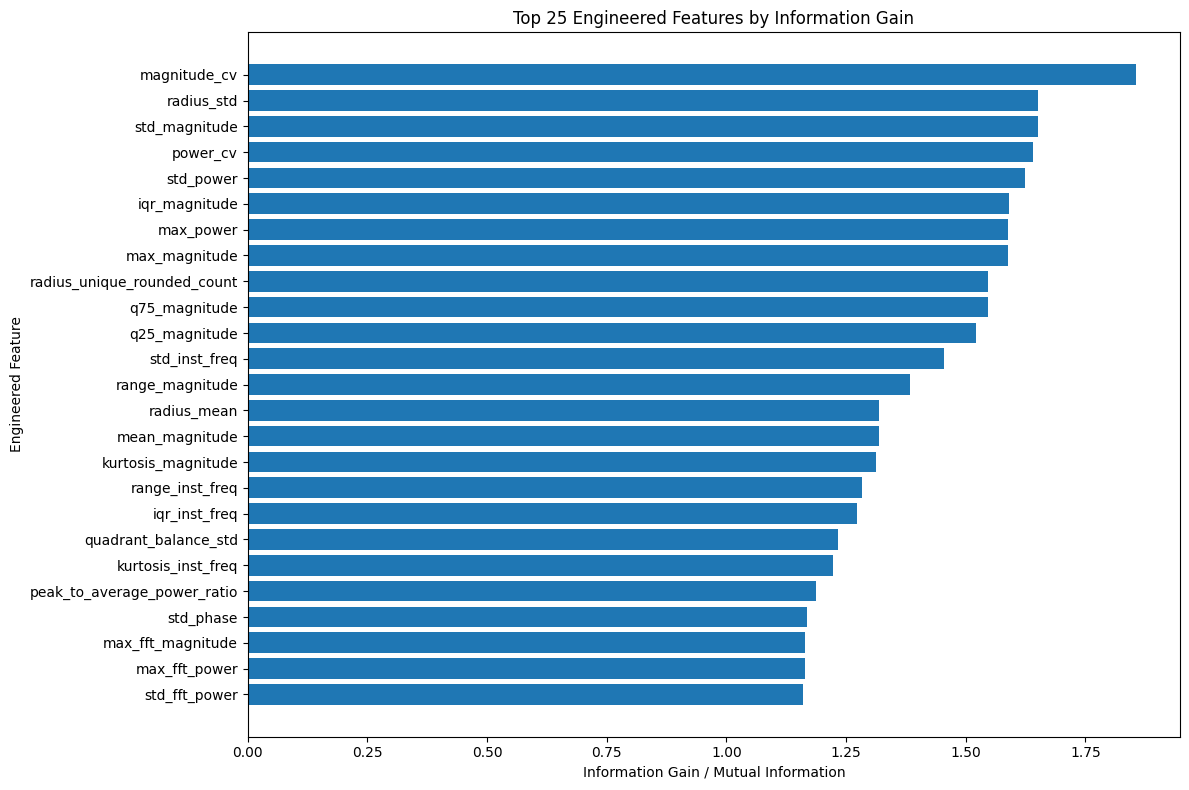

In [5]:
# Visualize the top information-gain features
e.plot_top_information_gain_features(
    information_gain_df=information_gain_df,
    top_n=25,
    figsize=(12, 8)
)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Random Forest Feature Importance Comparison

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- Train a simple Random Forest on the engineered features
- Compare model-based feature importance against information gain
- This is not the final model search; it is a secondary exploration check
- The trained engineered-feature Random Forest will be saved with a JSON in a later section

In [6]:
# Compare information gain against Random Forest feature importances
rf_model, random_forest_importance_df, model_metrics = e.calculate_random_forest_feature_importance(
    df_features=df_features,
    feature_columns=feature_columns,
    target_column='modulation_id',
    feature_dataset_filepath=e.FEATURE_ENGINEERED_DATASET_PARQUET,
    test_size=0.20,
    random_state=35,
    n_estimators=200,
    n_jobs=1
)

random_forest_importance_df.head(25)


RANDOM FOREST ON ENGINEERED FEATURES
Feature dataset filepath: ../Datasets/highest_snr_feature_engineered.parquet
X_train shape: (19200, 105)
X_test shape: (4800, 105)
Accuracy:              0.7217
Weighted Precision:    0.7120
Weighted Recall:       0.7217
Weighted ROC-AUC OVR:  0.9780

Top Random Forest feature importances:
                    feature  random_forest_importance  random_forest_importance_rank
 phase_unique_rounded_count                  0.032524                              1
              std_inst_freq                  0.031261                              2
              iqr_magnitude                  0.028011                              3
                  std_power                  0.025369                              4
              iqr_inst_freq                  0.024677                              5
radius_unique_rounded_count                  0.023866                              6
              q75_magnitude                  0.022418                        

,feature,random_forest_importance,random_forest_importance_rank
0,phase_unique_rounded_count,0.032524,1
1,std_inst_freq,0.031261,2
2,iqr_magnitude,0.028011,3
3,std_power,0.025369,4
4,iqr_inst_freq,0.024677,5
5,radius_unique_rounded_count,0.023866,6
6,q75_magnitude,0.022418,7
7,kurtosis_magnitude,0.022196,8
8,power_cv,0.021975,9
9,near_origin_ratio,0.021636,10


In [7]:
# View the quick model metrics from the engineered-feature Random Forest
model_metrics

{'project_stage': 'highest_snr_feature_engineering_explore',
 'model_type': 'RandomForestClassifier',
 'input_type': 'engineered_features',
 'dataset': {'feature_dataset_filepath': '../Datasets/highest_snr_feature_engineered.parquet',
  'dataset_shape': [24000, 109],
  'num_rows': 24000,
  'num_features_used': 105,
  'target_column': 'modulation_id',
  'mod_type_mapping': {'0': 'OOK',
   '1': '4ASK',
   '2': '8ASK',
   '3': 'BPSK',
   '4': 'QPSK',
   '5': '8PSK',
   '6': '16PSK',
   '7': '32PSK',
   '8': '16APSK',
   '9': '32APSK',
   '10': '64APSK',
   '11': '128APSK',
   '12': '16QAM',
   '13': '32QAM',
   '14': '64QAM',
   '15': '128QAM',
   '16': '256QAM',
   '17': 'AM-SSB-WC',
   '18': 'AM-SSB-SC',
   '19': 'AM-DSB-WC',
   '20': 'AM-DSB-SC',
   '21': 'FM',
   '22': 'GMSK',
   '23': 'OQPSK'}},
 'split': {'test_size': 0.2,
  'random_state': 35,
  'stratify': 'modulation_id',
  'train_indices': [12557,
   22185,
   19872,
   18245,
   19253,
   15338,
   22396,
   98,
   6617,
   233

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Feature Exploration Result Saving

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- Combine information gain and Random Forest feature importance into one table
- Save the ranked feature-exploration report to `../Reports/highest_snr_feature_exploration.csv`

In [8]:
# Combine both feature-ranking methods into one report
combined_feature_results_df = e.combine_feature_importance_results(
    information_gain_df=information_gain_df,
    random_forest_importance_df=random_forest_importance_df
)

# Save combined feature exploration results
e.save_feature_exploration_results(
    combined_feature_results_df=combined_feature_results_df,
    output_filepath=e.FEATURE_EXPLORATION_OUTPUT_PATH
)

combined_feature_results_df.head(25)

FEATURE EXPLORATION RESULTS SAVED
Output filepath: ../Reports/highest_snr_feature_exploration.csv
Saved shape: (105, 5)



,feature,information_gain,information_gain_rank,random_forest_importance,random_forest_importance_rank
0,magnitude_cv,1.854914,1,0.021065,12
1,radius_std,1.650984,2,0.019088,17
2,std_magnitude,1.650967,3,0.021118,11
3,power_cv,1.641041,4,0.021975,9
4,std_power,1.623681,5,0.025369,4
5,iqr_magnitude,1.591323,6,0.028011,3
6,max_power,1.588247,7,0.019856,14
7,max_magnitude,1.588221,8,0.021028,13
8,radius_unique_rounded_count,1.547279,9,0.023866,6
9,q75_magnitude,1.545803,10,0.022418,7


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Top Feature Selection for Modeling

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- Select the top features using information gain
- Save selected feature names to JSON so later modeling notebooks/scripts can reuse the same feature set
- Create `X_features`, `y_labels`, and `metadata_df` objects for model training

In [9]:
# Select top information-gain features for later model training
selected_feature_names = e.get_top_feature_names(
    information_gain_df=information_gain_df,
    top_n=25
)

# Save selected features to JSON for reproducibility
e.save_selected_feature_names(
    selected_feature_names=selected_feature_names,
    output_filepath=e.SELECTED_FEATURES_OUTPUT_PATH,
    selection_method='information_gain',
    top_n=25
)

Top 25 feature names:
1. magnitude_cv
2. radius_std
3. std_magnitude
4. power_cv
5. std_power
6. iqr_magnitude
7. max_power
8. max_magnitude
9. radius_unique_rounded_count
10. q75_magnitude
11. q25_magnitude
12. std_inst_freq
13. range_magnitude
14. radius_mean
15. mean_magnitude
16. kurtosis_magnitude
17. range_inst_freq
18. iqr_inst_freq
19. quadrant_balance_std
20. kurtosis_inst_freq
21. peak_to_average_power_ratio
22. std_phase
23. max_fft_magnitude
24. max_fft_power
25. std_fft_power
SELECTED FEATURE NAMES SAVED
Output filepath: ../Reports/highest_snr_selected_features.json
Number of selected features: 25



In [10]:
# Create a modeling-ready dataset using the selected engineered features
X_features, y_labels, metadata_df = e.create_modeling_dataset_from_top_features(
    df_features=df_features,
    top_feature_names=selected_feature_names
)

print('X_features shape:', X_features.shape)
print('y_labels shape:', y_labels.shape)
print('metadata_df shape:', metadata_df.shape)

X_features.head()

MODELING DATASET CREATED FROM TOP FEATURES
X_features shape: (24000, 25)
y_labels shape: (24000,)
metadata_df shape: (24000, 4)

X_features shape: (24000, 25)
y_labels shape: (24000,)
metadata_df shape: (24000, 4)


,magnitude_cv,radius_std,std_magnitude,power_cv,std_power,iqr_magnitude,max_power,max_magnitude,radius_unique_rounded_count,q75_magnitude,...,kurtosis_magnitude,range_inst_freq,iqr_inst_freq,quadrant_balance_std,kurtosis_inst_freq,peak_to_average_power_ratio,std_phase,max_fft_magnitude,max_fft_power,std_fft_power
0,0.853601,0.845569,0.845569,1.229004,2.084705,1.555150,7.706573,2.776072,241,1.780160,...,-1.216012,6.281568,0.002161,0.313410,15.776016,4.543287,1.330908,918.359863,8.433848e+05,26543.375000
1,0.804610,0.893427,0.893427,1.137210,2.309860,1.720923,8.524419,2.919661,242,1.959959,...,-1.382836,6.282243,0.001648,0.232467,19.739037,4.196815,1.348481,1036.359619,1.074041e+06,33805.968750
2,0.719524,0.885757,0.885757,1.015887,2.336544,1.727275,7.682770,2.771781,237,2.074491,...,-1.521644,6.279560,0.001601,0.337343,23.918617,3.340328,1.205052,1165.919800,1.359369e+06,42633.582031
3,0.720251,0.882576,0.882576,0.980888,2.236893,1.818861,7.788399,2.790770,241,2.088870,...,-1.598659,6.281272,0.001511,0.340138,25.251127,3.415249,1.195563,1171.939575,1.373442e+06,43048.007812
4,0.777153,0.892107,0.892107,1.079181,2.280922,1.760196,7.709262,2.776556,250,2.014971,...,-1.506608,6.278448,0.001709,0.331382,20.242563,3.647512,1.237347,1089.795898,1.187655e+06,37278.519531


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Engineered Feature Model Saving

- [Back to Table of Contents](#table-of-contents)

</div>


##### **SUMMARY**:
- Save the engineered-feature Random Forest model as a `.joblib` file
- Save the model metrics and reproducibility details as JSON
- Include train/test indices, model parameters, feature columns, package versions, information-gain rankings, selected features, and final test metrics


In [11]:
# Save engineered-feature Random Forest model and reproducibility JSON
e.save_engineered_feature_model(
    model=rf_model,
    model_metrics=model_metrics,
    model_output_path=e.ENGINEERED_FEATURE_MODEL_OUTPUT_PATH,
    metrics_output_path=e.ENGINEERED_FEATURE_METRICS_OUTPUT_PATH,
    information_gain_df=information_gain_df,
    combined_feature_results_df=combined_feature_results_df,
    selected_feature_names=selected_feature_names,
    save_model=True,
    save_metrics_json=True
)


ENGINEERED-FEATURE MODEL SAVE COMPLETE
Model saved to: ../Models/highest_snr_feature_engineered_random_forest.joblib
Metrics JSON saved to: ../Models/highest_snr_feature_engineered_random_forest_metrics.json



<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Main Function Check

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- `e.main()` runs the full exploration workflow in one call, including model and JSON saving
- Keep this commented out if you already ran the notebook step-by-step above

In [13]:
e.main()

Feature-engineered dataset loaded successfully!
Dataset filepath: ../Datasets/highest_snr_feature_engineered.parquet
Dataset shape: (24000, 109)

Number of feature columns: 105
FEATURE-ENGINEERED DATASET SUMMARY
Dataset shape: (24000, 109)
Number of rows/signals: 24000
Number of engineered features: 105

Modulation distribution:
modulation_type
128APSK      1000
128QAM       1000
16APSK       1000
16PSK        1000
16QAM        1000
256QAM       1000
32APSK       1000
32PSK        1000
32QAM        1000
4ASK         1000
64APSK       1000
64QAM        1000
8ASK         1000
8PSK         1000
AM-DSB-SC    1000
AM-DSB-WC    1000
AM-SSB-SC    1000
AM-SSB-WC    1000
BPSK         1000
FM           1000
GMSK         1000
OOK          1000
OQPSK        1000
QPSK         1000
Name: count, dtype: int64

SNR distribution:
snr
30    24000
Name: count, dtype: int64

First 5 rows:
   signal_index  modulation_id modulation_type  snr    mean_I     std_I  \
0             0              0             O